In [ ]:
# Directives on Jupyter
%reset
# Auto reload bootstrap.py
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np

import sys
import os

module_path = os.path.abspath(os.path.join("../src"))
if module_path not in sys.path:
    sys.path.append(module_path)

output_path = os.path.abspath("../../../OneDrive - Rice University/Documents/Research/Hubbard Tweezer Parameters/output/GB/")

from HubbardTweezer.Hubbard.plot import *
from HubbardTweezer.Hubbard.io import *
from HubbardTweezer.Hubbard.core import wannier_func
from HubbardTweezer.tools.fix_phase import fix_phase
from HubbardTweezer.tools.funcs import tweezer_potential, shaking_potential

# Harmonic trap

## No AOD traps

Lattice: lattice shape is square; lattice constants set to: (2310, 2310)
Wannier: Number of integration grid set to 257.
DVR: dx=[0.25 0.25 0.6 ]w is set.
DVR: n=[12 12 12] is set.
DVR: R0=[3.  3.  7.2]w is set.
['x' 'y' 'z']-reflection symmetry is used.
param_set: trap parameter V0=31.2549kHz w=700nm
Lattice: lattice shape is square; lattice constants set to: [3.3 3.3]
Lattice: lattice shape is square
Lattice: Full lattice sizes: [13  1]
Lattice: lattice constants: [3.3 3.3]w
Lattice: dx fixed to: [0.25 0.25 0.6 ]w
DVR: dx=[0.25 0.25 0.6 ]w is set.
DVR: n=[91 12 12] is set.
DVR: R0=[22.8  3.   7.2]w is set.
Equalize: scale_factor is not a number. Set to None.
Illegal x0 provided. Use no initial guess.
Equalize: initial guess:  [  1.    1.    1.    1.    1.    1.    1.  -19.8 -16.5 -13.2  -9.9  -6.6
  -3.3]

Equalize: Initial trap depths: [1. 1. 1. 1. 1. 1. 1.]
Equalize: Initial trap centers:
[[-19.8   0. ]
 [-16.5   0. ]
 [-13.2   0. ]
 [ -9.9   0. ]
 [ -6.6   0. ]
 [ -3.3   0. ]
 [  

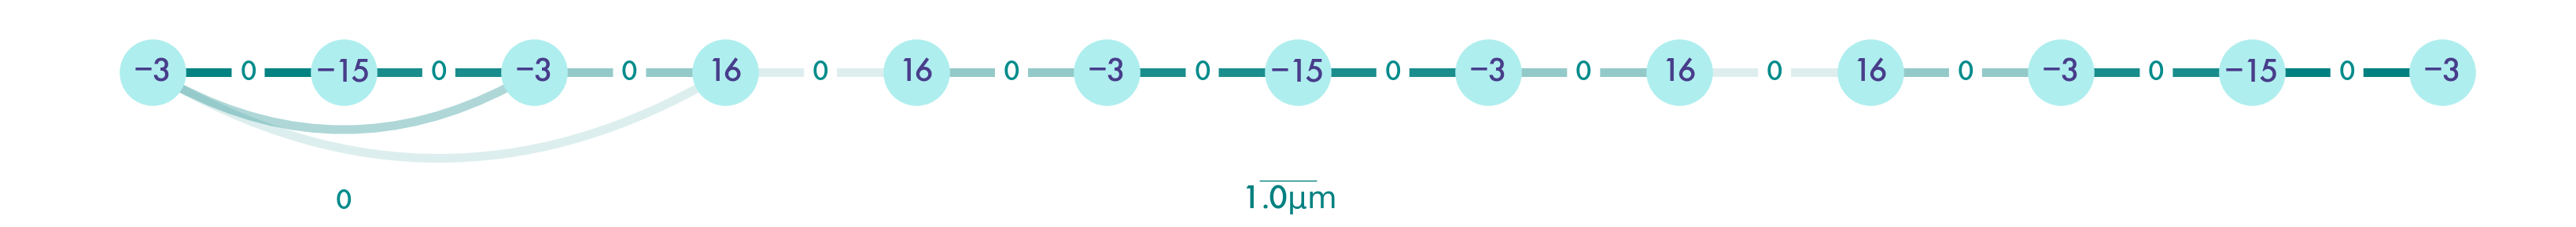

In [67]:
N = 12
L = 13
Ly = 1
d = 3
shape = "square"
w = 700
lc = 2310
eqt = "neq"
R0 = np.array([3, 3, 7.2])

lattice = Lattice(
    shape=shape,  # lattice geometries
    lattice_symmetry=True,  # lattice reflection symmetry
    lattice=np.array([L, Ly], dtype=int),  # lattice size
    lc=(lc,),  # lattice constant
    nodes=None,  # custom lattice site positions
    links=None,  # custom lattice links
    isotropic=False,  # check if the lattice is isotropic
    ghost=False,
)

G = HubbardGraph(
    N,
    R0=R0,
    atom=87.905612253,  # 88 Sr
    trap=(31.2549, w),
    ascatt=0,
    zR=2000,
    lattice=lattice,
    band=1,
    dim=d,
    sparse=True,
    shape=shape,
    variable_waist=None,
    equalize=False,
    eqitem=eqt,
    lattice_symmetry=True,
    symmetry=True,
    verbosity=3,
)
G.calculate_U = False
# fn = os.path.join(output_path, f"{d}D_{L}x{Ly}_{shape}_{w}_{eqt}.ini")
# read_file(fn, G)
G.draw_graph(nnn=2)

Trap frequency

In [72]:
np.sqrt(2 * G.hb * G.V0 / G.m) / G.w / (2 * np.pi)

np.float64(3829.9341793151298)

In [68]:
G.omega / (2 * np.pi)  # Trap frequency

array([5416.34485938, 5416.34485938, 1358.43230273])

The trap freq is smaller than tunneling rate. Band mixing?

In [36]:
G.A * 1000

array([[-3.26087981e+00, -2.03032765e-01, -4.41548050e-02,
        -8.57523965e-03,  3.07925493e-03, -6.03709474e-03,
        -5.31625227e-03,  3.25280863e-03,  1.02412983e-03,
        -6.76572173e-04, -1.51918854e-03, -1.56965487e-03,
        -1.09418200e-03],
       [-2.03032765e-01, -1.50962182e+01,  2.02800686e-01,
         2.41215899e-02, -5.93374598e-03,  1.10296826e-02,
         9.08483249e-03, -5.29642357e-03, -1.61693921e-03,
         1.01551254e-03,  2.24777982e-03,  2.28392363e-03,
         1.56965487e-03],
       [-4.41548050e-02,  2.02800686e-01, -3.26162044e+00,
         7.36632281e-02, -8.43285764e-03,  1.47603199e-02,
         1.10211198e-02, -6.01053857e-03, -1.76164486e-03,
         1.03714914e-03,  2.25695154e-03,  2.24777982e-03,
         1.51918854e-03],
       [-8.57523965e-03,  2.41215899e-02,  7.36632281e-02,
         1.62142673e+01, -8.27106951e-03,  8.43146047e-03,
         5.92831661e-03, -3.06562880e-03, -8.67983155e-04,
         4.83373083e-04,  1.03714915e

## With AOD traps

Lattice: lattice shape is square; lattice constants set to: (1155, 1155)
Wannier: Number of integration grid set to 257.
DVR: dx=[0.1875 0.1875 0.45  ]w is set.
DVR: n=[16 16 16] is set.
DVR: R0=[3.  3.  7.2]w is set.
['x' 'y' 'z']-reflection symmetry is used.
param_set: trap parameter V0=31.2549kHz w=700nm
Lattice: lattice shape is square; lattice constants set to: [1.65 1.65]
Lattice: lattice shape is square
Lattice: Full lattice sizes: [25  1]
Lattice: lattice constants: [1.65 1.65]w
Lattice: dx fixed to: [0.1875 0.1875 0.45  ]w
DVR: dx=[0.1875 0.1875 0.45  ]w is set.
DVR: n=[121  16  16] is set.
DVR: R0=[22.8  3.   7.2]w is set.
Equalize: scale_factor is not a number. Set to None.
Illegal x0 provided. Use no initial guess.
Equalize: initial guess:  [  1.     1.     1.     1.     1.     1.     1.     1.     1.     1.
   1.     1.     1.   -19.8  -18.15 -16.5  -14.85 -13.2  -11.55  -9.9
  -8.25  -6.6   -4.95  -3.3   -1.65]

Equalize: Initial trap depths: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1

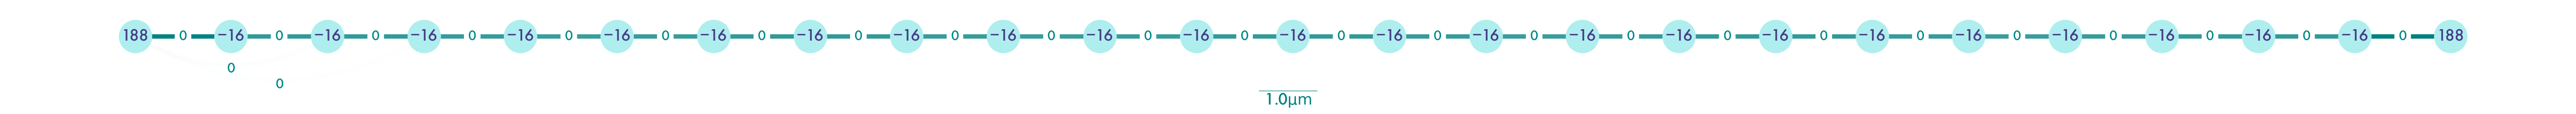

In [281]:
N = 16
L = 25
Ly = 1
d = 3
lc = 1155
# lc = 900
w = 700
V0 = 31.2549
shape = "square"
eqt = "neq"
R0 = np.array([3, 3, 7.2])

lattice = Lattice(
    shape=shape,  # lattice geometries
    lattice_symmetry=True,  # lattice reflection symmetry
    lattice=np.array([L, Ly], dtype=int),  # lattice size
    lc=(lc,),  # lattice constant
    nodes=None,  # custom lattice site positions
    links=None,  # custom lattice links
    isotropic=False,  # check if the lattice is isotropic
    ghost=False,
)

G = HubbardGraph(
    N,
    R0=R0,
    atom=87.905612253,  # 88 Sr
    trap=(V0, w),
    ascatt=0,
    zR=2000,
    lattice=lattice,
    band=1,
    dim=d,
    sparse=True,
    shape=shape,
    variable_waist=False,
    equalize=False,
    eqitem=eqt,
    lattice_symmetry=True,
    symmetry=True,
    verbosity=3,
)
G.calculate_U = False
# fn = os.path.join(output_path, f"{d}D_{L}x{Ly}_{shape}_{w}_{eqt}.ini")
# read_file(fn, G)
G.draw_graph(nnn=2)

In [282]:
G.A * 1000

array([[ 1.88019076e+02, -1.22647326e-01,  5.38243007e-05,
         2.37188236e-05,  8.91107295e-06, -9.44302801e-06,
        -1.80341167e-05, -1.73583125e-05,  1.10384181e-05,
        -3.01031924e-06,  3.64691489e-06,  7.22283457e-06,
        -7.42323338e-06, -5.05806640e-06, -1.52394455e-06,
        -1.74627388e-06, -3.72347907e-06, -4.01446812e-06,
        -2.85485427e-06,  9.11412230e-07, -1.01109781e-06,
         2.25604532e-06, -2.50679775e-06, -1.83629783e-06,
        -5.15972967e-07],
       [-1.22647326e-01, -1.63818685e+01,  1.13352304e-01,
        -4.64826032e-04, -4.50160537e-05,  9.86755240e-05,
         1.27845383e-04,  1.03194104e-04, -5.82815791e-05,
         1.39354445e-05, -1.79644049e-05, -3.29396728e-05,
         3.23333886e-05,  2.12230065e-05,  6.11129547e-06,
         7.13719857e-06,  1.47362004e-05,  1.55614764e-05,
         1.08688351e-05, -3.39333875e-06,  3.79540329e-06,
        -8.32257230e-06,  9.13972852e-06,  6.62485148e-06,
         1.83629809e-06],
    

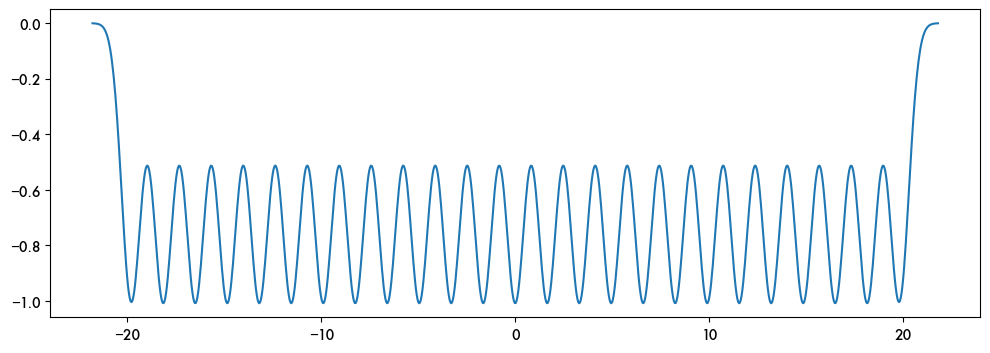

In [283]:
x = np.linspace(lattice.trap_centers[0][0] - 2, lattice.trap_centers[-1][0] + 2, 1000)
f = plt.figure(figsize=(12, 4))
plt.plot(x, G.Vfun(x, 0, 0))

## Closer lc

Lattice: lattice shape is square; lattice constants set to: (900, 900)
Wannier: Number of integration grid set to 257.
DVR: dx=[0.1875 0.1875 0.45  ]w is set.
DVR: n=[16 16 16] is set.
DVR: R0=[3.  3.  7.2]w is set.
['x' 'y' 'z']-reflection symmetry is used.
param_set: trap parameter V0=31.2549kHz w=700nm
Lattice: lattice shape is square; lattice constants set to: [1.28571429 1.28571429]
Lattice: lattice shape is square
Lattice: Full lattice sizes: [25  1]
Lattice: lattice constants: [1.28571429 1.28571429]w
Lattice: dx fixed to: [0.1875 0.1875 0.45  ]w
DVR: dx=[0.1875 0.1875 0.45  ]w is set.
DVR: n=[98 16 16] is set.
DVR: R0=[18.42857143  3.          7.2       ]w is set.
Equalize: scale_factor is not a number. Set to None.
Illegal x0 provided. Use no initial guess.
Equalize: initial guess:  [  1.           1.           1.           1.           1.
   1.           1.           1.           1.           1.
   1.           1.           1.         -15.42857143 -14.14285714
 -12.85714286 -

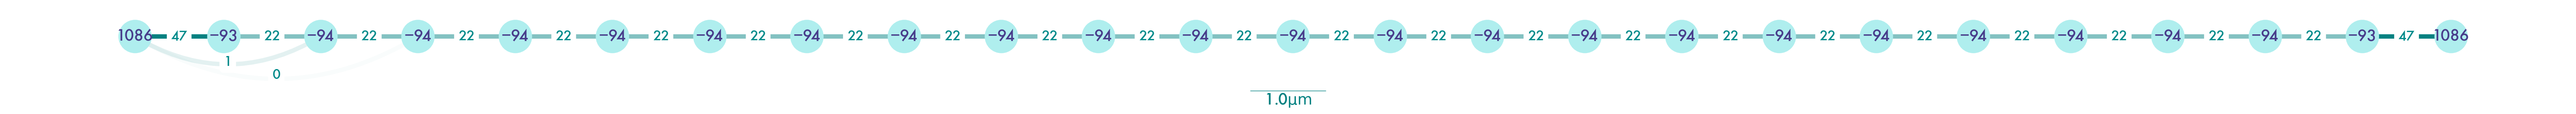

In [284]:
N = 16
L = 25
Ly = 1
d = 3
# lc = 1155
lc = 900
w = 700
V0 = 31.2549
shape = "square"
eqt = "neq"
R0 = np.array([3, 3, 7.2])

lattice = Lattice(
    shape=shape,  # lattice geometries
    lattice_symmetry=True,  # lattice reflection symmetry
    lattice=np.array([L, Ly], dtype=int),  # lattice size
    lc=(lc,),  # lattice constant
    nodes=None,  # custom lattice site positions
    links=None,  # custom lattice links
    isotropic=False,  # check if the lattice is isotropic
    ghost=False,
)

G = HubbardGraph(
    N,
    R0=R0,
    atom=87.905612253,  # 88 Sr
    trap=(V0, w),
    ascatt=0,
    zR=2000,
    lattice=lattice,
    band=1,
    dim=d,
    sparse=True,
    shape=shape,
    variable_waist=False,
    equalize=False,
    eqitem=eqt,
    lattice_symmetry=True,
    symmetry=True,
    verbosity=3,
)
G.calculate_U = False
# fn = os.path.join(output_path, f"{d}D_{L}x{Ly}_{shape}_{w}_{eqt}.ini")
# read_file(fn, G)
G.draw_graph(nnn=2)

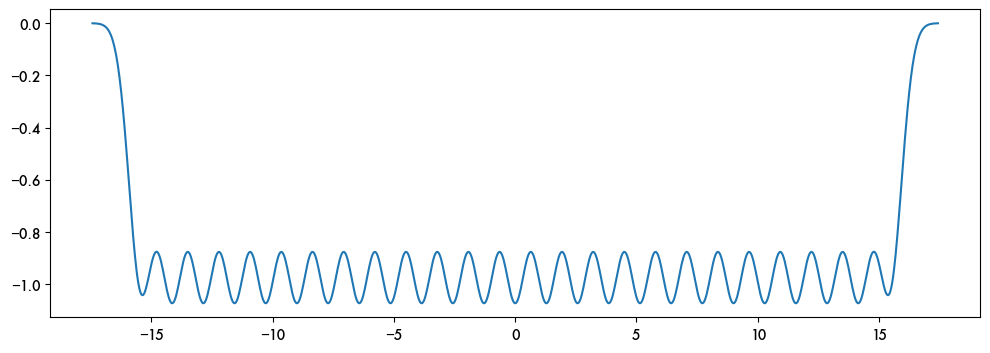

In [285]:
x = np.linspace(lattice.trap_centers[0][0] - 2, lattice.trap_centers[-1][0] + 2, 1000)
f = plt.figure(figsize=(12, 4))
plt.plot(x, G.Vfun(x, 0, 0))

## Wider waist traps

Most exaggerated trap, let all waists enlarged by the $\pm 0.4\mu\text{m}$ shaking.

Wannier: Number of integration grid set to 257.
DVR: dx=[0.25 0.25 0.6 ]w is set.
DVR: n=[12 12 12] is set.
DVR: R0=[3.  3.  7.2]w is set.
['x' 'y' 'z']-reflection symmetry is used.
param_set: trap parameter V0=31.2549kHz w=1500nm
Lattice: lattice shape is square; lattice constants set to: (1155, 1155)
Lattice: lattice shape is square
Lattice: Full lattice sizes: [25  1]
Lattice: lattice constants: [0.77 0.77]w
Lattice: dx fixed to: [0.25 0.25 0.6 ]w
DVR: dx=[0.25 0.25 0.6 ]w is set.
DVR: n=[48 12 12] is set.
DVR: R0=[12.24  3.    7.2 ]w is set.
Equalize: scale_factor is not a number. Set to None.
Illegal x0 provided. Use no initial guess.
Equalize: initial guess:  [ 1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.
  1.   -9.24 -8.47 -7.7  -6.93 -6.16 -5.39 -4.62 -3.85 -3.08 -2.31 -1.54
 -0.77]

Equalize: Initial trap depths: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Equalize: Initial trap centers:
[[-9.24  0.  ]
 [-8.47  0.  ]
 [-7.7   0.  ]
 [-6.93  0.  ]
 [-6.16  

/Users/nottforestfc/miniforge3/envs/torch/lib/python3.13/site-packages/numpy/_core/numeric.py:1211: RuntimeWarning: divide by zero encountered in dot
  res = dot(at, bt)
/Users/nottforestfc/miniforge3/envs/torch/lib/python3.13/site-packages/numpy/_core/numeric.py:1211: RuntimeWarning: overflow encountered in dot
  res = dot(at, bt)
/Users/nottforestfc/miniforge3/envs/torch/lib/python3.13/site-packages/numpy/_core/numeric.py:1211: RuntimeWarning: invalid value encountered in dot
  res = dot(at, bt)


H_solver: Gaussian Hamiltonian solved. Time spent: 0.11s.
H_solver: eigenstates memory usage:  1.61 MiB.
Energies: [-1.58724426 -1.5871611  -1.58702262 -1.58682886 -1.58657998 -1.58627614
 -1.58591754 -1.5855044  -1.58503697 -1.58451551 -1.58394029 -1.5833116
 -1.5826297  -1.58189487 -1.58110735 -1.58026734 -1.57937499 -1.57843028
 -1.57743285 -1.57638134 -1.57526976 -1.57389697 -1.57313684 -1.5728775
 -1.57279424 -1.57265557 -1.57246156 -1.57221235 -1.57190815 -1.57175604
 -1.57154907 -1.57113541 -1.57066746 -1.57044461 -1.57014535 -1.56956945
 -1.56909097 -1.56893998 -1.56825743 -1.56769077 -1.5675218  -1.56673347
 -1.56624272 -1.56589263 -1.56500023 -1.56474515 -1.5640538  -1.56320058
 -1.56305542 -1.56200297 -1.56160692 -1.55996491]
parities: [array([[ 1,  1,  1],
       [-1,  1,  1],
       [ 1,  1,  1],
       [-1,  1,  1],
       [ 1,  1,  1],
       [-1,  1,  1],
       [ 1,  1,  1],
       [-1,  1,  1],
       [ 1,  1,  1],
       [-1,  1,  1],
       [ 1,  1,  1],
       [-1,

<string>:21: RuntimeWarning: divide by zero encountered in matmul
<string>:21: RuntimeWarning: overflow encountered in matmul
<string>:21: RuntimeWarning: invalid value encountered in matmul
/Users/nottforestfc/Projects/DVR-code/src/HubbardTweezer/Hubbard/core.py:676: RuntimeWarning: divide by zero encountered in matmul
  # Extract information into symmetrized first sector
/Users/nottforestfc/Projects/DVR-code/src/HubbardTweezer/Hubbard/core.py:676: RuntimeWarning: overflow encountered in matmul
  # Extract information into symmetrized first sector
/Users/nottforestfc/Projects/DVR-code/src/HubbardTweezer/Hubbard/core.py:676: RuntimeWarning: invalid value encountered in matmul
  # Extract information into symmetrized first sector


Single band interaction time: 8.266711950302124s.

Start to plot graph...


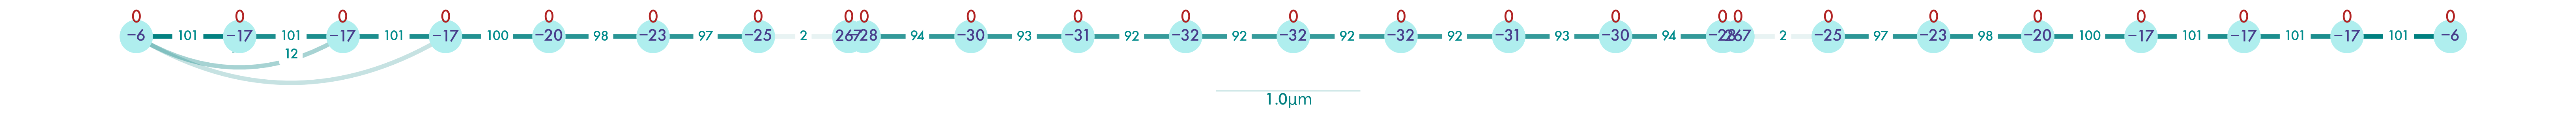

In [39]:
N = 12
L = 25
Ly = 1
d = 3
shape = "square"
w = None
eqt = "neq"
R0 = np.array([3, 3, 7.2])
G = HubbardGraph(
    N,
    R0=R0,
    atom=87.905612253,  # 88 Sr
    lattice_params=(np.array([L, Ly], dtype=int), (1155,)),
    trap=(31.2549, 700 + 800),
    ascatt=0,
    zR=2000,
    band=1,
    dim=d,
    sparse=True,
    shape=shape,
    waist=w,
    equalize=False,
    eqitem=eqt,
    lattice_symmetry=True,
    symmetry=True,
    verbosity=3,
)
# fn = os.path.join(output_path, f"{d}D_{L}x{Ly}_{shape}_{w}_{eqt}.ini")
# read_file(fn, G)
G.draw_graph(nnn=2)

Why the order doesn't match?

Expectation: 2kHz, now at most 100Hz

1. Check atom mass
2. Check beam waists
3. Check Wannierization
4. Implement this special potential function

# Time-averaged traps

In [243]:
N = 16
Ls = 13
L = 25
Ly = 1
d = 3
shape = "square"
w = 700
wxy = (1, 1)
zR0 = 2000 / w
zR = (zR0, zR0)
amp = 200 / w
lc = 1155 / w
eqt = "neq"
R0 = np.array([3, 3, 7.2])

physical_lattice = Lattice(
    shape=shape,  # lattice geometries
    lattice_symmetry=True,  # lattice reflection symmetry
    lattice=np.array([Ls, Ly], dtype=int),  # lattice size
    lc=(2 * lc,),  # lattice constant
    nodes=None,  # custom lattice site positions
    links=None,  # custom lattice links
    isotropic=False,  # check if the lattice is isotropic
    ghost=False,
)
lattice = Lattice(
    shape=shape,  # lattice geometries
    lattice_symmetry=True,  # lattice reflection symmetry
    lattice=np.array([L, Ly], dtype=int),  # lattice size
    lc=(lc,),  # lattice constant
    nodes=None,  # custom lattice site positions
    links=None,  # custom lattice links
    isotropic=False,  # check if the lattice is isotropic
    ghost=False,
)


def custom_potential(x, y, z):
    """Custom trapping potential."""
    V = 0
    for i in range(lattice.N):
        shift = lattice.trap_centers[i]
        if np.any(np.all(shift == physical_lattice.trap_centers, axis=1)):
            # Only apply potential if the site is in the physical lattice
            V += tweezer_potential(
                x - shift[0] / wxy[0], y - shift[1] / wxy[1], z, wxy, zR, zR0
            )
        else:
            V += shaking_potential(
                x - shift[0] / wxy[0], y - shift[1] / wxy[1], z, amp, wxy, zR, zR0
            )
    return V

Lattice: lattice shape is square; lattice constants set to: (3.3, 3.3)
Lattice: lattice shape is square; lattice constants set to: (1.65, 1.65)


Lattice: lattice shape is square; lattice constants set to: (1.65, 1.65)


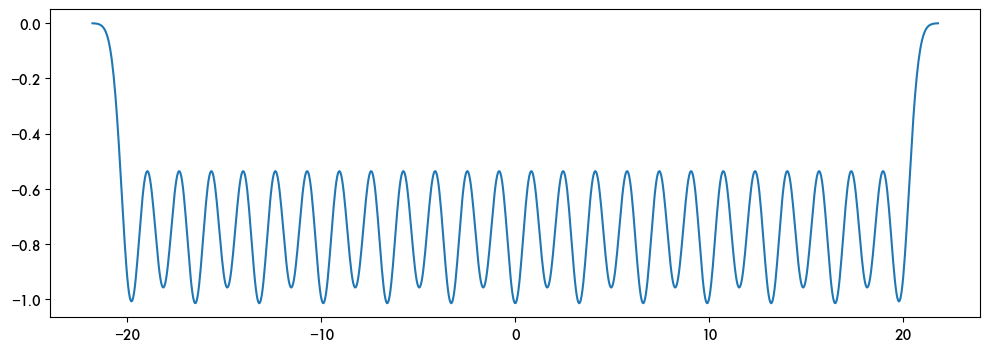

In [244]:
N = 16
Ls = 13
L = 25
Ly = 1
d = 3
shape = "square"
w = 700
wxy = (1, 1)
zR0 = 2000
zR = (zR0, zR0)
amp = 200
lc = 1155 / w
eqt = "neq"
R0 = np.array([3, 3, 7.2])

physical_indices = np.arange(0, L, 2)
lattice = Lattice(
    shape=shape,  # lattice geometries
    lattice_symmetry=True,  # lattice reflection symmetry
    lattice=np.array([L, Ly], dtype=int),  # lattice size
    lc=(lc,),  # lattice constant
    nodes=None,  # custom lattice site positions
    links=None,  # custom lattice links
    isotropic=False,  # check if the lattice is isotropic
    ghost=False,
)


def custom_potential(x, y, z):
    """Custom trapping potential."""
    V = 0
    for i in range(lattice.N):
        shift = lattice.trap_centers[i]
        if i in physical_indices:
            # Only apply potential if the site is in the physical lattice
            V += tweezer_potential(
                x - shift[0] / wxy[0],
                y - shift[1] / wxy[1],
                z,
                wxy,
                (zR[0] / w, zR[1] / w),
                zR0 / w,
            )
        else:
            V += shaking_potential(
                x - shift[0] / wxy[0],
                y - shift[1] / wxy[1],
                z,
                amp / w,
                wxy,
                (zR[0] / w, zR[1] / w),
                zR0 / w,
            )
    return V


x = np.linspace(lattice.trap_centers[0][0] - 2, lattice.trap_centers[-1][0] + 2, 1000)
f = plt.figure(figsize=(12, 4))
plt.plot(x, custom_potential(x, 0, 0))

## One band

Lattice: lattice shape is square; lattice constants set to: (3.3, 3.3)
Lattice: lattice shape is square; lattice constants set to: (1.65, 1.65)
Wannier: Number of integration grid set to 257.
Wannier: Custom potential model is set. Ignore lattice parameters.
DVR: dx=[0.1875 0.1875 0.45  ]w is set.
DVR: n=[16 16 16] is set.
DVR: R0=[3.  3.  7.2]w is set.
['x' 'y' 'z']-reflection symmetry is used.
param_set: trap parameter V0=31.2549kHz w=700nm
Lattice: lattice shape is square
Lattice: Full lattice sizes: [25  1]
Lattice: lattice constants: [1.65 1.65]w
Lattice: dx fixed to: [0.1875 0.1875 0.45  ]w
DVR: dx=[0.1875 0.1875 0.45  ]w is set.
DVR: n=[121  16  16] is set.
DVR: R0=[22.8  3.   7.2]w is set.
Equalize: scale_factor is not a number. Set to None.
Illegal x0 provided. Use no initial guess.
Equalize: initial guess:  [  1.     1.     1.     1.     1.     1.     1.     1.     1.     1.
   1.     1.     1.   -19.8  -18.15 -16.5  -14.85 -13.2  -11.55  -9.9
  -8.25  -6.6   -4.95  -3.3   -1

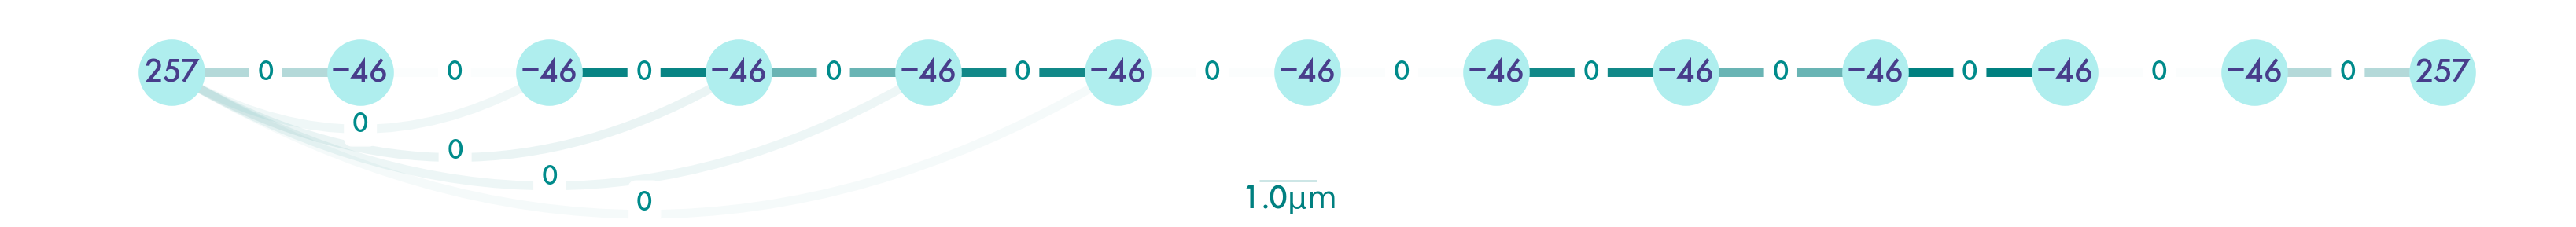

In [273]:
N = 16
Ls = 13
L = 25
Ly = 1
band = 1
d = 3
shape = "square"
V0 = 31.2549
w = 700
wxy = (1, 1)
zR0 = 2000
zR = (zR0, zR0)
amp = 200
lc = 1155 / w
eqt = "neq"
R0 = np.array([3, 3, 7.2])

physical_indices = np.arange(0, L, 2)
physical_lattice = Lattice(
    shape=shape,  # lattice geometries
    lattice_symmetry=True,  # lattice reflection symmetry
    lattice=np.array([Ls, Ly], dtype=int),  # lattice size
    lc=(2 * lc,),  # lattice constant
    nodes=None,  # custom lattice site positions
    links=None,  # custom lattice links
    isotropic=False,  # check if the lattice is isotropic
    ghost=False,
)
lattice = Lattice(
    shape=shape,  # lattice geometries
    lattice_symmetry=True,  # lattice reflection symmetry
    lattice=np.array([L, Ly], dtype=int),  # lattice size
    lc=(lc,),  # lattice constant
    nodes=None,  # custom lattice site positions
    links=None,  # custom lattice links
    isotropic=False,  # check if the lattice is isotropic
    ghost=False,
)


def custom_potential(x, y, z):
    """Custom trapping potential."""
    V = 0
    for i in range(lattice.N):
        shift = lattice.trap_centers[i]
        if i in physical_indices:
            # Only apply potential if the site is in the physical lattice
            V += tweezer_potential(
                x - shift[0] / wxy[0],
                y - shift[1] / wxy[1],
                z,
                wxy,
                (zR[0] / w, zR[1] / w),
                zR0 / w,
            )
        else:
            V += shaking_potential(
                x - shift[0] / wxy[0],
                y - shift[1] / wxy[1],
                z,
                amp / w,
                wxy,
                (zR[0] / w, zR[1] / w),
                zR0 / w,
            )
    return V


G = HubbardGraph(
    N,
    R0=R0,
    atom=87.905612253,  # 88 Sr
    trap=(V0, w),
    ascatt=0,
    zR=zR,
    lattice=lattice,  # Use custom lattice
    model="custom",  # Use custom potential
    custom_potential=custom_potential,  # Custom trapping potential
    band=band,
    dim=d,
    sparse=True,
    shape=shape,
    variable_waist=None,
    equalize=False,
    eqitem=eqt,
    lattice_symmetry=True,
    symmetry=True,
    verbosity=3,
)
G.calculate_U = False
G.lattice = physical_lattice  # Use physical lattice for graph drawing
G.update_graph()
eig_sol = G.eigen_basis()
maskedA, W, wf_centers, wf_costs = G.multiband_WF(*eig_sol)
values = {}
for i in range(band):
    Vi = np.real(np.diag(maskedA[i]))
    tij = abs(np.real(maskedA[i] - np.diag(Vi)))
    values[f"t_{i+1}_ij"] = tij
    values[f"V_{i+1}_i"] = Vi
    values[f"wf_{i+1}_centers"] = wf_centers[i]
    values[f"wf_{i+1}_cost"] = wf_costs[i]

if G.calculate_U:
    U = interaction(G, W, *eig_sol[1:])
    for i in range(band):
        for j in range(band):
            values[f"U_{i+1}{j+1}_i"] = U[i, j]

G.draw_graph(nnn=4)

In [246]:
G.omega / (2 * np.pi)  # Trap frequency

array([5416.34485938, 5416.34485938, 1895.72070078])

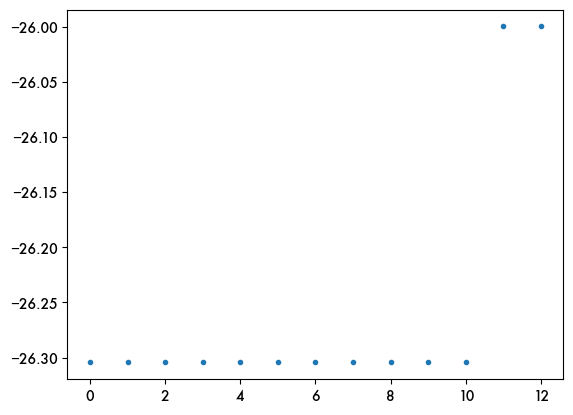

In [247]:
plt.plot(eig_sol[0][0] * V0, ".")

In [274]:
values["t_1_ij"] * 1000

array([[0.00000000e+00, 1.16453939e-04, 5.86489384e-06, 1.04479167e-05,
        7.03926802e-06, 2.37427781e-06, 4.96309139e-06, 1.03382990e-06,
        2.54045321e-06, 1.96050758e-06, 6.97601851e-07, 1.73598974e-06,
        2.95368063e-07],
       [1.16453939e-04, 0.00000000e+00, 3.64257428e-07, 2.33214676e-04,
        8.69022898e-05, 2.57285074e-05, 4.25558431e-05, 7.58521521e-06,
        1.82448353e-05, 1.31077073e-05, 4.55068829e-06, 1.07326714e-05,
        1.73598824e-06],
       [5.86489384e-06, 3.64257428e-07, 0.00000000e+00, 6.05704387e-04,
        8.32507861e-05, 2.07458416e-05, 2.56961323e-05, 3.79997316e-06,
        9.03871428e-06, 6.01040703e-06, 2.04249743e-06, 4.55069132e-06,
        6.97608579e-07],
       [1.04479167e-05, 2.33214676e-04, 6.05704387e-04, 0.00000000e+00,
        3.73585793e-04, 8.32482118e-05, 8.67983015e-05, 1.16769371e-05,
        2.77144427e-05, 1.78396340e-05, 6.01040905e-06, 1.31077061e-05,
        1.96051463e-06],
       [7.03926802e-06, 8.69022898e-

Single band optimization time: 0.004665851593017578s.


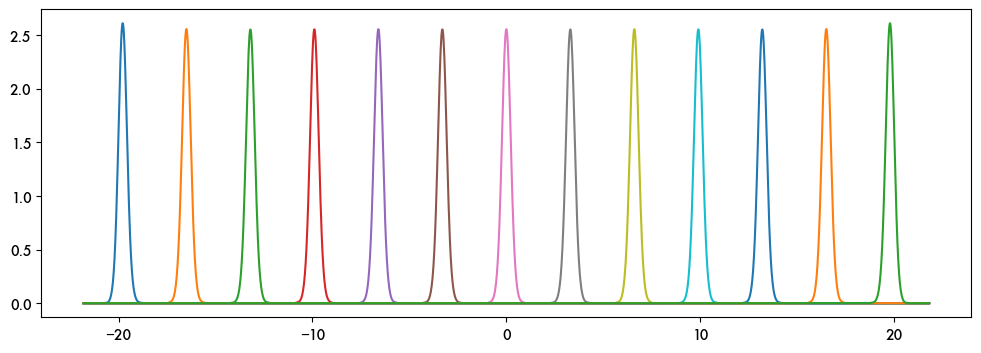

In [248]:
E_mixed, W_mixed, p_mixed = eig_sol
A, WF = G.singleband_WF(E=E_mixed[0], W=W_mixed[0], parity=p_mixed[0])

x = np.linspace(lattice.trap_centers[0][0] - 2, lattice.trap_centers[-1][0] + 2, 2000)
wfx = wannier_func((x, 0, 0), WF, G, W_mixed[0], p_mixed[0])

plt.figure(figsize=(12, 4))
for i in range(physical_lattice.N):
    plt.plot(x, fix_phase(wfx[:, :, :, i].flatten()), "-", label=f"WF {i+1}")

## Two band

### mixed low bands

In [253]:
N = 16
Ls = 13
L = 25
Ly = 1
band = 2
d = 3
shape = "square"
w = 700
wxy = (1, 1)
zR0 = 2000
zR = (zR0, zR0)
amp = 200
lc = 1155 / w
eqt = "neq"
R0 = np.array([3, 3, 7.2])

physical_indices = np.arange(0, L, 2)
physical_lattice = Lattice(
    shape=shape,  # lattice geometries
    lattice_symmetry=True,  # lattice reflection symmetry
    lattice=np.array([Ls, Ly], dtype=int),  # lattice size
    lc=(2 * lc,),  # lattice constant
    nodes=None,  # custom lattice site positions
    links=None,  # custom lattice links
    isotropic=False,  # check if the lattice is isotropic
    ghost=False,
)
lattice = Lattice(
    shape=shape,  # lattice geometries
    lattice_symmetry=True,  # lattice reflection symmetry
    lattice=np.array([L, Ly], dtype=int),  # lattice size
    lc=(lc,),  # lattice constant
    nodes=None,  # custom lattice site positions
    links=None,  # custom lattice links
    isotropic=False,  # check if the lattice is isotropic
    ghost=False,
)


def custom_potential(x, y, z):
    """Custom trapping potential."""
    V = 0
    for i in range(lattice.N):
        shift = lattice.trap_centers[i]
        if i in physical_indices:
            # Only apply potential if the site is in the physical lattice
            V += tweezer_potential(
                x - shift[0] / wxy[0],
                y - shift[1] / wxy[1],
                z,
                wxy,
                (zR[0] / w, zR[1] / w),
                zR0 / w,
            )
        else:
            V += shaking_potential(
                x - shift[0] / wxy[0],
                y - shift[1] / wxy[1],
                z,
                amp / w,
                wxy,
                (zR[0] / w, zR[1] / w),
                zR0 / w,
            )
    return V


G = HubbardGraph(
    N,
    R0=R0,
    atom=87.905612253,  # 88 Sr
    trap=(31.2549, w),
    ascatt=0,
    zR=zR,
    lattice=lattice,  # Use custom lattice
    model="custom",  # Use custom potential
    custom_potential=custom_potential,  # Custom trapping potential
    band=band,
    dim=d,
    sparse=True,
    shape=shape,
    variable_waist=None,
    equalize=False,
    eqitem=eqt,
    lattice_symmetry=True,
    symmetry=True,
    verbosity=3,
)
G.calculate_U = False
# G.lattice = physical_lattice  # Use physical lattice for graph drawing
# G.update_graph()
band_site = G.lattice.N * 2
k = band_site * G.bands
if G.dvr_symm:
    p_list = G.build_sectors()
    E_sb = np.array([])
    W_sb = []
    p_sb = np.array([], dtype=int).reshape(0, DIM)
    for pidx in range(len(p_list)):
        p = p_list[pidx]
        W0p = None
        E_sb, W_sb, p_sb = G.solve_sector(p, k + 1, E_sb, W_sb, p_sb, W0p)

    idx = np.argsort(E_sb)
    E_sb = E_sb[idx]
    W_sb = [W_sb[i] for i in idx]
    p_sb = p_sb[idx, :]
else:
    p_sb = np.zeros((k, DIM))
    E_sb, W_sb = G.H_solver(k + 1)
    W_sb = [W_sb[:, i].reshape(2 * G.n + 1) for i in range(k)]

print(f"Energies: {E_sb}")
print(f"parities: {[p_sb]}")
# elif self.verbosity > 1 and E_sb[k - 1] - E_sb[0] > E_sb[k] - E_sb[k - 1]:
#     print("Wannier warning: band gap is smaller than band width.")

# Hand coded pz-even and pz-odd bands
E_even = np.array([])
E_odd = np.array([])
W_even = []
W_odd = []
parity_even = np.array([], dtype=int).reshape(0, DIM)
parity_odd = np.array([], dtype=int).reshape(0, DIM)
count_even = 0
count_odd = 0
for pidx in range(len(p_sb)):
    p = p_sb[pidx]
    if p[2] == 1 and count_even < band_site:
        E_even = np.append(E_even, E_sb[pidx])
        W_even.append(W_sb[pidx])
        parity_even = np.append(parity_even, p[None], axis=0)
        count_even += 1
    elif p[2] == -1 and count_odd < band_site:
        E_odd = np.append(E_odd, E_sb[pidx])
        W_odd.append(W_sb[pidx])
        parity_odd = np.append(parity_odd, p[None], axis=0)
        count_odd += 1
    E = [E_even, E_odd]
    W = [W_even, W_odd]
    parity = [parity_even, parity_odd]

Lattice: lattice shape is square; lattice constants set to: (3.3, 3.3)
Lattice: lattice shape is square; lattice constants set to: (1.65, 1.65)
Wannier: Number of integration grid set to 257.
Wannier: Custom potential model is set. Ignore lattice parameters.
DVR: dx=[0.1875 0.1875 0.45  ]w is set.
DVR: n=[16 16 16] is set.
DVR: R0=[3.  3.  7.2]w is set.
['x' 'y' 'z']-reflection symmetry is used.
param_set: trap parameter V0=31.2549kHz w=700nm
Lattice: lattice shape is square
Lattice: Full lattice sizes: [25  1]
Lattice: lattice constants: [1.65 1.65]w
Lattice: dx fixed to: [0.1875 0.1875 0.45  ]w
DVR: dx=[0.1875 0.1875 0.45  ]w is set.
DVR: n=[121  16  16] is set.
DVR: R0=[22.8  3.   7.2]w is set.
Equalize: scale_factor is not a number. Set to None.
Illegal x0 provided. Use no initial guess.
Equalize: initial guess:  [  1.     1.     1.     1.     1.     1.     1.     1.     1.     1.
   1.     1.     1.   -19.8  -18.15 -16.5  -14.85 -13.2  -11.55  -9.9
  -8.25  -6.6   -4.95  -3.3   -1

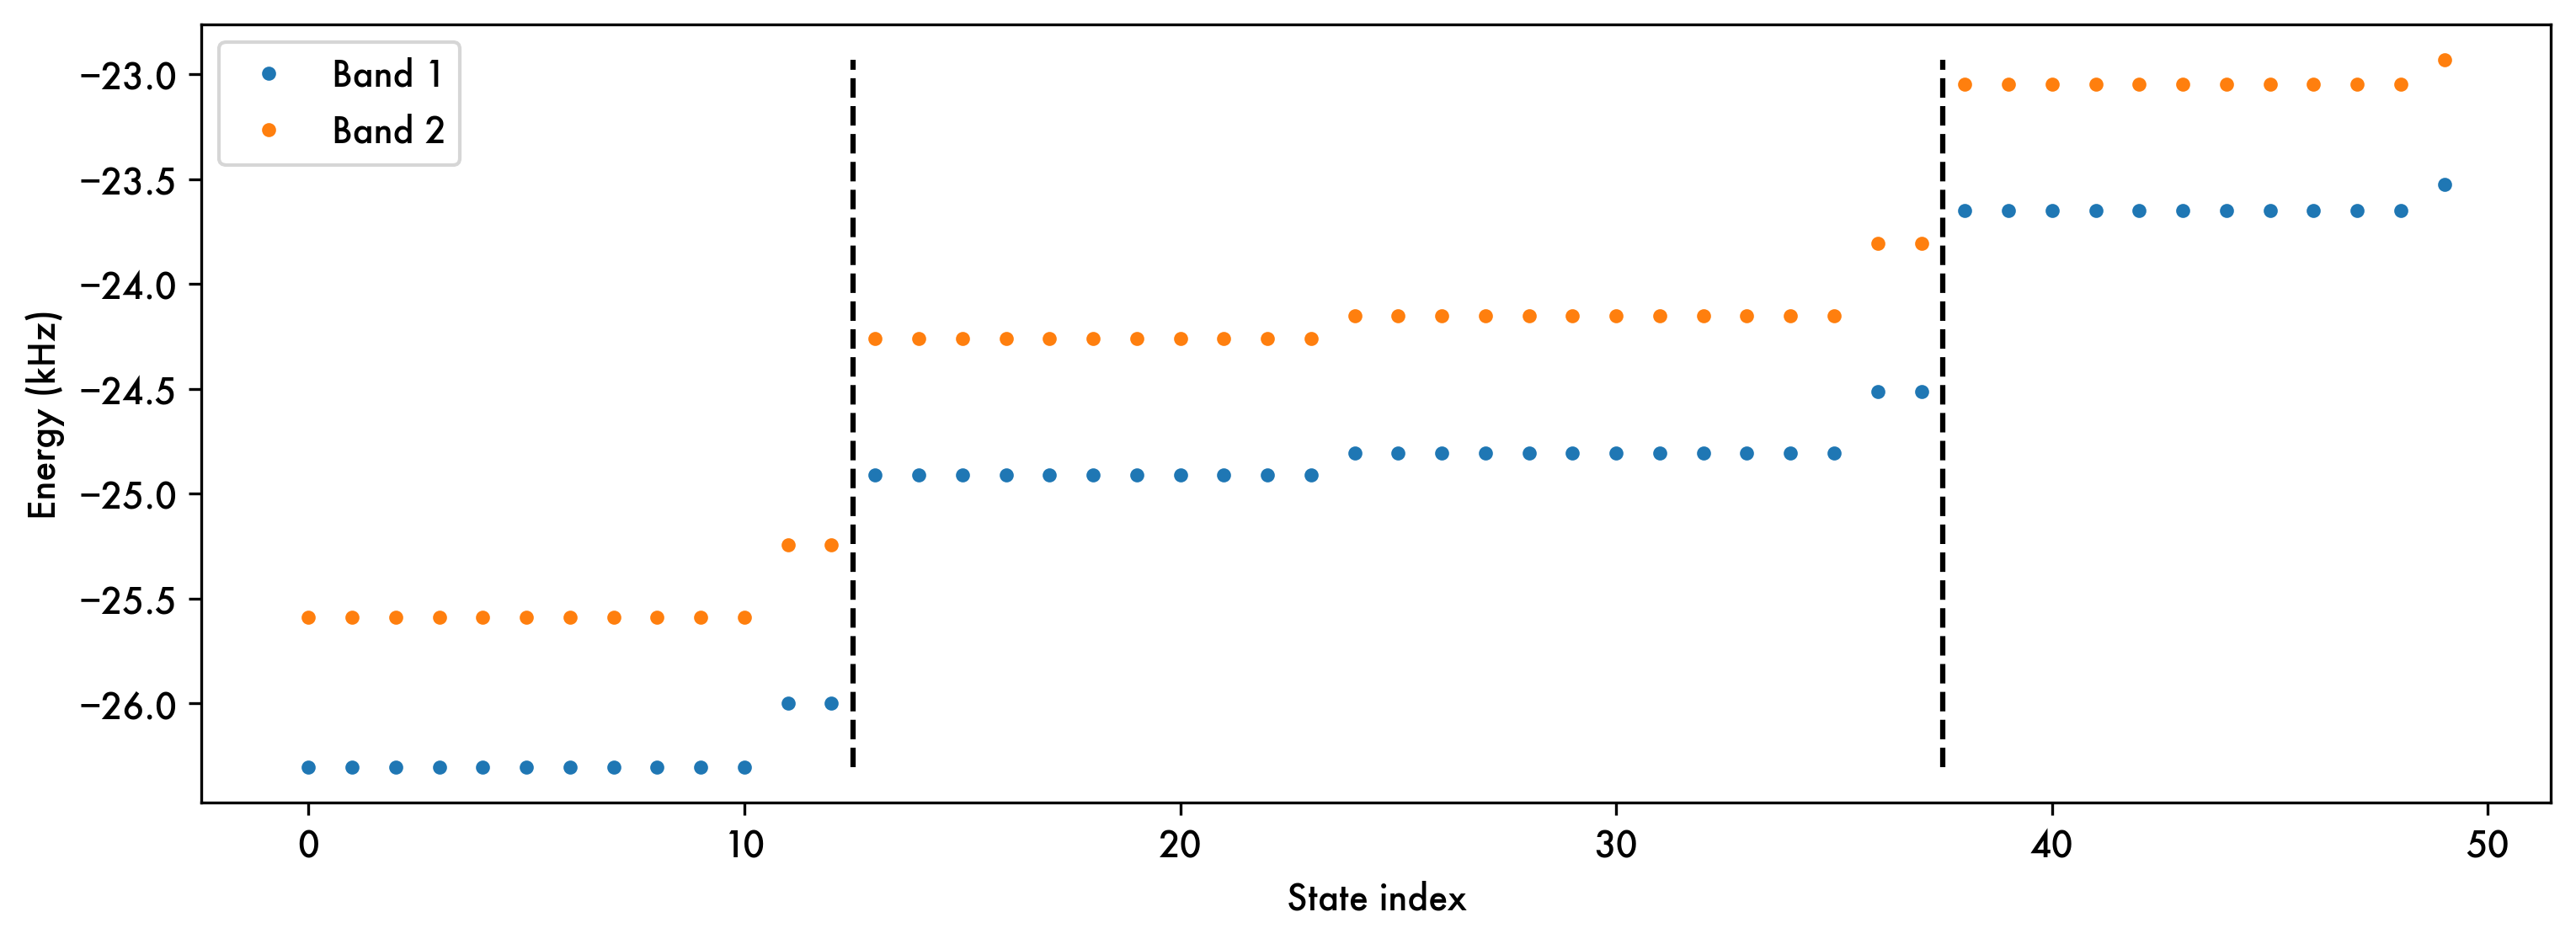

In [254]:
plt.figure(figsize=(12, 4), dpi=300)
for b in range(band):
    plt.plot(E[b] * V0, ".", label=f"Band {b+1}")
plt.vlines(
    Ls - 0.5, ymin=E[0][0] * V0, ymax=E[1][-1] * V0, colors="k", linestyles="dashed"
)
plt.vlines(
    L + Ls - 0.5, ymin=E[0][0] * V0, ymax=E[1][-1] * V0, colors="k", linestyles="dashed"
)
plt.xlabel("State index")
plt.ylabel("Energy (kHz)")
plt.legend()

#### Even band

Single band optimization time: 0.013541936874389648s.
Single band optimization time: 0.013502836227416992s.

Start to plot graph...


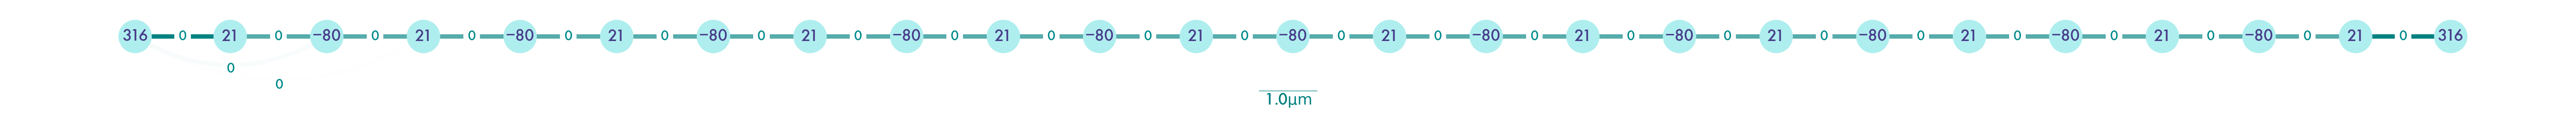

In [266]:
E_mixed = E[0][Ls : Ls + L]
W_mixed = W[0][Ls : Ls + L]
p_mixed = parity[0][Ls : Ls + L]
A, WF = G.singleband_WF(E=E_mixed, W=W_mixed, parity=p_mixed)
G.draw_graph(eig_sol=([E_mixed], [W_mixed], [p_mixed]))

In [269]:
G.A * 1000

array([[ 3.16332464e+02,  1.07035371e-01,  1.41865088e-04,
         5.65485204e-06,  2.64534373e-06,  1.76953475e-06,
         3.61841021e-06, -2.57063077e-06,  2.83950644e-06,
         4.05657662e-07, -9.80904346e-07, -9.97442761e-07,
        -2.12422140e-06, -6.79723979e-07,  4.50308828e-07,
        -2.36167499e-07,  1.11408309e-06, -5.31212550e-07,
         8.66127396e-07, -1.18391632e-07,  3.10074297e-07,
         2.95728411e-07, -7.74469789e-07, -2.38722821e-07,
         1.23155233e-07],
       [ 1.07035371e-01,  2.11376519e+01, -7.71122530e-02,
        -2.74267007e-04, -5.35955094e-06, -3.61389796e-05,
        -1.38689952e-05,  3.72149553e-05, -6.38432612e-06,
        -4.90972443e-06,  1.93879072e-06,  1.19794482e-05,
         3.52739338e-06,  7.67320442e-06, -6.74346039e-07,
         2.61723767e-06, -1.60516073e-06,  5.65232107e-06,
        -1.18824907e-06,  1.22024041e-06, -4.11934904e-07,
        -3.03084608e-06,  9.97417349e-07,  2.40473233e-06,
        -2.38725050e-07],
    

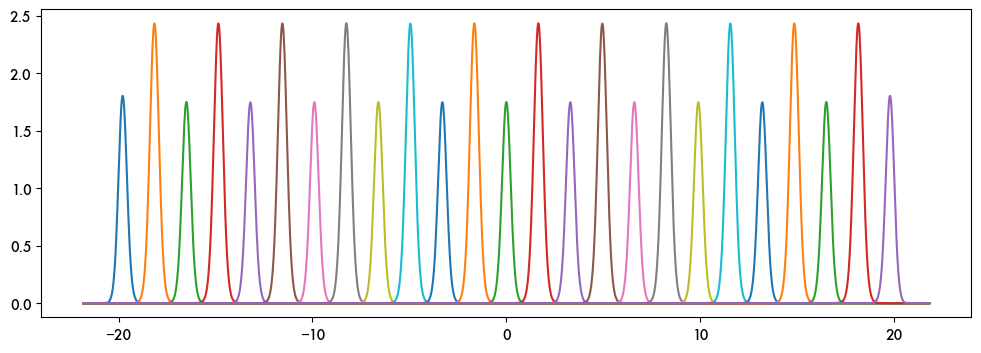

In [258]:
x = np.linspace(lattice.trap_centers[0][0] - 2, lattice.trap_centers[-1][0] + 2, 2000)
wfx = wannier_func((x, 0, 0), WF, G, W_mixed, p_mixed)
plt.figure(figsize=(12, 4))
for i in range(lattice.N):
    plt.plot(x, fix_phase(wfx[:, :, :, i].flatten()), "-", label=f"WF {i+1}")

#### Odd band

Single band optimization time: 0.010756969451904297s.
Single band optimization time: 0.0080718994140625s.

Start to plot graph...


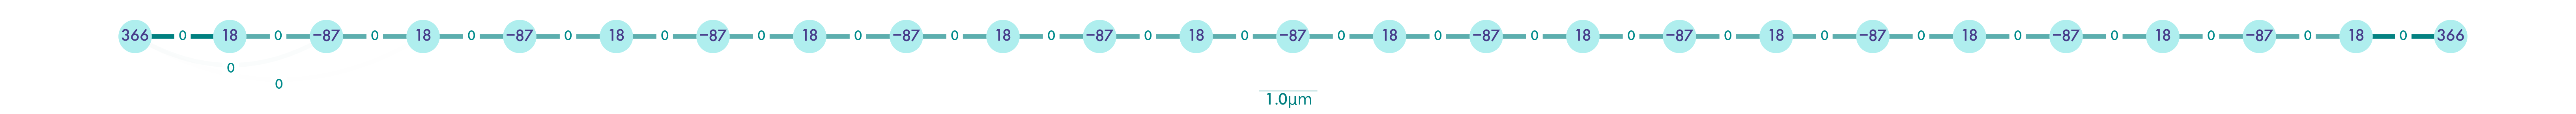

In [270]:
E_mixed = E[1][Ls : Ls + L]
W_mixed = W[1][Ls : Ls + L]
p_mixed = parity[1][Ls : Ls + L]
A, WF = G.singleband_WF(E=E_mixed, W=W_mixed, parity=p_mixed)
G.draw_graph(nnn=2, eig_sol=([E_mixed], [W_mixed], [p_mixed]))

In [272]:
G.A * 1000

array([[ 3.66369978e+02,  2.88423544e-01, -2.42926234e-04,
         6.28064920e-06, -2.06113415e-06, -2.04381298e-06,
        -2.61462610e-06,  3.01785922e-06,  2.10502223e-06,
        -4.76014821e-07, -7.26205573e-07, -1.18547734e-06,
        -1.58383752e-06, -8.07918787e-07,  3.37020850e-07,
         2.82699357e-07,  8.32862836e-07,  6.34177162e-07,
         6.48351206e-07,  1.40862062e-07, -2.32091243e-07,
        -3.53962199e-07,  5.80266221e-07,  2.85508872e-07,
         9.89271741e-08],
       [ 2.88423544e-01,  1.88623709e+01,  1.98695586e-01,
        -4.13322154e-04,  6.27265848e-06,  2.47249690e-05,
         1.69626373e-05, -2.53507277e-05, -7.78392586e-06,
         3.32107262e-06,  2.38403139e-06,  8.18102659e-06,
         4.31537567e-06,  5.23095108e-06, -8.20414631e-07,
        -1.79176729e-06, -1.96650070e-06, -3.85857892e-06,
        -1.45318706e-06, -8.30516909e-07,  5.05790060e-07,
         2.07058759e-06, -1.22128284e-06, -1.64107807e-06,
        -2.85501576e-07],
    

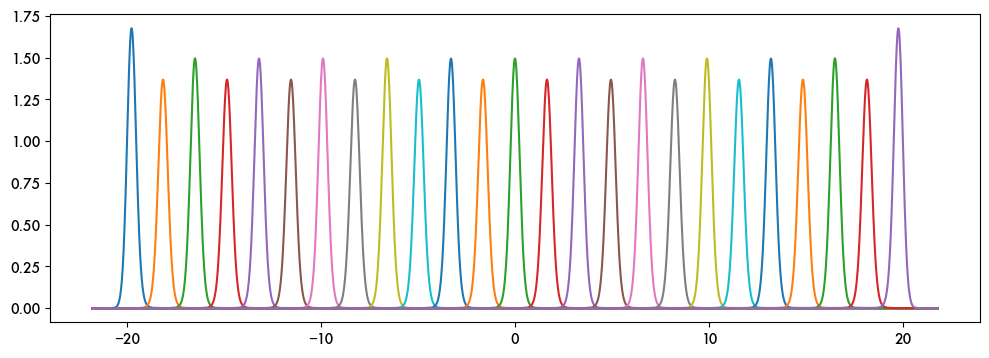

In [261]:
x = np.linspace(lattice.trap_centers[0][0] - 2, lattice.trap_centers[-1][0] + 2, 2000)
wfx = wannier_func((x, 0, 1), WF, G, W_mixed, p_mixed)
plt.figure(figsize=(12, 4))
for i in range(lattice.N):
    plt.plot(x, fix_phase(wfx[:, :, :, i].flatten()), "-", label=f"WF {i+1}")

### Tunneling table

| SLM site tunneling | AOD + SLM site tunneling |
|---|---|
| $\sim 10^{-3}$ Hz | $\sim 0.1$ Hz |

### pz bands

In [111]:
N = 12
Ls = 13
L = 25
Ly = 1
band = 2
d = 3
shape = "square"
w = 700
wxy = (1, 1)
zR0 = 2000
zR = (zR0, zR0)
amp = 200
lc = 1155 / w
eqt = "neq"
R0 = np.array([3, 3, 7.2])

physical_indices = np.arange(0, L, 2)
physical_lattice = Lattice(
    shape=shape,  # lattice geometries
    lattice_symmetry=True,  # lattice reflection symmetry
    lattice=np.array([Ls, Ly], dtype=int),  # lattice size
    lc=(2 * lc,),  # lattice constant
    nodes=None,  # custom lattice site positions
    links=None,  # custom lattice links
    isotropic=False,  # check if the lattice is isotropic
    ghost=False,
)
lattice = Lattice(
    shape=shape,  # lattice geometries
    lattice_symmetry=True,  # lattice reflection symmetry
    lattice=np.array([L, Ly], dtype=int),  # lattice size
    lc=(lc,),  # lattice constant
    nodes=None,  # custom lattice site positions
    links=None,  # custom lattice links
    isotropic=False,  # check if the lattice is isotropic
    ghost=False,
)


def custom_potential(x, y, z):
    """Custom trapping potential."""
    V = 0
    for i in range(lattice.N):
        shift = lattice.trap_centers[i]
        if i in physical_indices:
            # Only apply potential if the site is in the physical lattice
            V += tweezer_potential(
                x - shift[0] / wxy[0],
                y - shift[1] / wxy[1],
                z,
                wxy,
                (zR[0] / w, zR[1] / w),
                zR0 / w,
            )
        else:
            V += shaking_potential(
                x - shift[0] / wxy[0],
                y - shift[1] / wxy[1],
                z,
                amp / w,
                wxy,
                (zR[0] / w, zR[1] / w),
                zR0 / w,
            )
    return V


G = HubbardGraph(
    N,
    R0=R0,
    atom=87.905612253,  # 88 Sr
    trap=(31.2549, w),
    ascatt=0,
    zR=zR,
    lattice=lattice,  # Use custom lattice
    model="custom",  # Use custom potential
    custom_potential=custom_potential,  # Custom trapping potential
    band=band,
    dim=d,
    sparse=True,
    shape=shape,
    variable_waist=None,
    equalize=False,
    eqitem=eqt,
    lattice_symmetry=True,
    symmetry=True,
    verbosity=3,
)
G.calculate_U = False
G.calculate_U = False
G.lattice = physical_lattice  # Use physical lattice for graph drawing
G.update_graph()
eig_sol = G.eigen_basis(band_std="symmetry")
maskedA, W, wf_centers, wf_costs = G.multiband_WF(*eig_sol)
values = {}
for i in range(band):
    Vi = np.real(np.diag(maskedA[i]))
    tij = abs(np.real(maskedA[i] - np.diag(Vi)))
    values[f"t_{i+1}_ij"] = tij
    values[f"V_{i+1}_i"] = Vi
    values[f"wf_{i+1}_centers"] = wf_centers[i]
    values[f"wf_{i+1}_cost"] = wf_costs[i]

if G.calculate_U:
    U = interaction(G, W, *eig_sol[1:])
    for i in range(band):
        for j in range(band):
            values[f"U_{i+1}{j+1}_i"] = U[i, j]

# G.draw_graph(nnn=4)

Lattice: lattice shape is square; lattice constants set to: (3.3, 3.3)
Lattice: lattice shape is square; lattice constants set to: (1.65, 1.65)
Wannier: Number of integration grid set to 257.
Wannier: Custom potential model is set. Ignore lattice parameters.
DVR: dx=[0.25 0.25 0.6 ]w is set.
DVR: n=[12 12 12] is set.
DVR: R0=[3.  3.  7.2]w is set.
['x' 'y' 'z']-reflection symmetry is used.
param_set: trap parameter V0=31.2549kHz w=700nm
Lattice: lattice shape is square
Lattice: Full lattice sizes: [25  1]
Lattice: lattice constants: [1.65 1.65]w
Lattice: dx fixed to: [0.25 0.25 0.6 ]w
DVR: dx=[0.25 0.25 0.6 ]w is set.
DVR: n=[91 12 12] is set.
DVR: R0=[22.8  3.   7.2]w is set.
Equalize: scale_factor is not a number. Set to None.
Illegal x0 provided. Use no initial guess.
Equalize: initial guess:  [  1.     1.     1.     1.     1.     1.     1.     1.     1.     1.
   1.     1.     1.   -19.8  -18.15 -16.5  -14.85 -13.2  -11.55  -9.9
  -8.25  -6.6   -4.95  -3.3   -1.65]

Equalize: Initi

In [81]:
G.omega / (2 * np.pi)  # Trap frequency

array([5416.34485938, 5416.34485938, 1895.72070078])

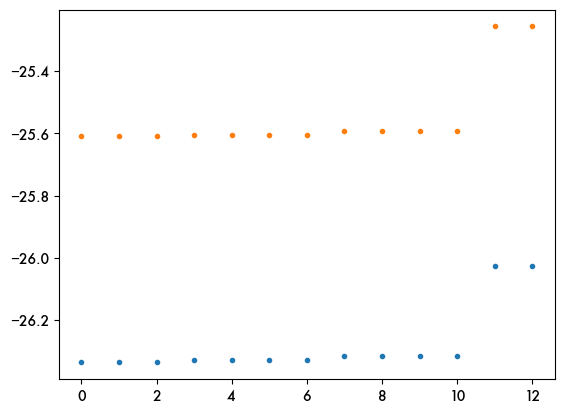

In [ ]:
plt.plot(eig_sol[0][0] * V0, ".")
plt.plot(eig_sol[0][1] * V0, ".")

In [ ]:
values["t_1_ij"]

array([[0.00000000e+00, 1.40512122e-04, 3.13004295e-05, 6.14352945e-06,
        2.17302698e-06, 4.32762874e-06, 3.83320362e-06, 2.34651439e-06,
        7.39198136e-07, 4.84664480e-07, 1.09731423e-06, 1.13914729e-06,
        9.56742033e-07],
       [1.40512122e-04, 0.00000000e+00, 1.21480749e-04, 1.44470956e-05,
        3.53856056e-06, 6.61969232e-06, 5.46730146e-06, 3.18195140e-06,
        9.68698134e-07, 6.07586989e-07, 1.35122358e-06, 1.37773963e-06,
        1.13914728e-06],
       [3.13004295e-05, 1.21480749e-04, 0.00000000e+00, 4.38720258e-05,
        5.00234857e-06, 8.82629426e-06, 6.60941692e-06, 3.59865100e-06,
        1.05187141e-06, 6.18358745e-07, 1.35205201e-06, 1.35122357e-06,
        1.09731422e-06],
       [6.14352945e-06, 1.44470956e-05, 4.38720258e-05, 0.00000000e+00,
        4.92148935e-06, 5.00085968e-06, 3.53219383e-06, 1.82517104e-06,
        5.15600988e-07, 2.86810065e-07, 6.18358742e-07, 6.07586992e-07,
        4.84664494e-07],
       [2.17302698e-06, 3.53856056e-

In [ ]:
values["t_2_ij"]

array([[0.00000000e+00, 1.10016962e-04, 2.47382269e-05, 4.88382355e-06,
        1.69021061e-06, 3.40808259e-06, 3.02814742e-06, 1.85436034e-06,
        5.85049660e-07, 3.80138146e-07, 8.65493505e-07, 9.00307329e-07,
        7.81118790e-07],
       [1.10016962e-04, 0.00000000e+00, 9.27646211e-05, 1.11237363e-05,
        2.66193741e-06, 5.04845043e-06, 4.18222785e-06, 2.43451369e-06,
        7.41963908e-07, 4.61656347e-07, 1.03197114e-06, 1.05418948e-06,
        9.00307328e-07],
       [2.47382269e-05, 9.27646211e-05, 0.00000000e+00, 3.33442842e-05,
        3.71482736e-06, 6.70234292e-06, 5.04052520e-06, 2.74665399e-06,
        8.04157943e-07, 4.68614204e-07, 1.03049163e-06, 1.03197114e-06,
        8.65493508e-07],
       [4.88382355e-06, 1.11237363e-05, 3.33442842e-05, 0.00000000e+00,
        3.86212272e-06, 3.71369610e-06, 2.65706979e-06, 1.37942734e-06,
        3.91108095e-07, 2.15944416e-07, 4.68614203e-07, 4.61656344e-07,
        3.80138149e-07],
       [1.69021061e-06, 2.66193741e-

In [ ]:
values["wf_1_centers"][:, 0]

array([-1.97786259e+01, -1.64999999e+01, -1.32023704e+01, -9.90148768e+00,
       -6.59851232e+00, -3.29762954e+00,  7.40757276e-16,  3.29762954e+00,
        6.59851232e+00,  9.90148768e+00,  1.32023704e+01,  1.64999999e+01,
        1.97786259e+01])

In [ ]:
values["wf_2_centers"][:, 0]

array([-1.97752210e+01, -1.64999999e+01, -1.32019212e+01, -9.90120169e+00,
       -6.59879831e+00, -3.29807875e+00, -1.60393896e-15,  3.29807875e+00,
        6.59879831e+00,  9.90120169e+00,  1.32019212e+01,  1.64999999e+01,
        1.97752210e+01])

## Multi band

In [125]:
N = 12
Ls = 13
L = 25
Ly = 1
band = 3
d = 3
shape = "square"
w = 700
wxy = (1, 1)
zR0 = 2000
zR = (zR0, zR0)
amp = 200
lc = 1155 / w
eqt = "neq"
R0 = np.array([3, 3, 7.2])

physical_indices = np.arange(0, L, 2)
physical_lattice = Lattice(
    shape=shape,  # lattice geometries
    lattice_symmetry=True,  # lattice reflection symmetry
    lattice=np.array([Ls, Ly], dtype=int),  # lattice size
    lc=(2 * lc,),  # lattice constant
    nodes=None,  # custom lattice site positions
    links=None,  # custom lattice links
    isotropic=False,  # check if the lattice is isotropic
    ghost=False,
)
lattice = Lattice(
    shape=shape,  # lattice geometries
    lattice_symmetry=True,  # lattice reflection symmetry
    lattice=np.array([L, Ly], dtype=int),  # lattice size
    lc=(lc,),  # lattice constant
    nodes=None,  # custom lattice site positions
    links=None,  # custom lattice links
    isotropic=False,  # check if the lattice is isotropic
    ghost=False,
)


def custom_potential(x, y, z):
    """Custom trapping potential."""
    V = 0
    for i in range(lattice.N):
        shift = lattice.trap_centers[i]
        if i in physical_indices:
            # Only apply potential if the site is in the physical lattice
            V += tweezer_potential(
                x - shift[0] / wxy[0],
                y - shift[1] / wxy[1],
                z,
                wxy,
                (zR[0] / w, zR[1] / w),
                zR0 / w,
            )
        else:
            V += shaking_potential(
                x - shift[0] / wxy[0],
                y - shift[1] / wxy[1],
                z,
                amp / w,
                wxy,
                (zR[0] / w, zR[1] / w),
                zR0 / w,
            )
    return V


G = HubbardGraph(
    N,
    R0=R0,
    atom=87.905612253,  # 88 Sr
    trap=(31.2549, w),
    ascatt=0,
    zR=zR,
    lattice=lattice,  # Use custom lattice
    model="custom",  # Use custom potential
    custom_potential=custom_potential,  # Custom trapping potential
    band=band,
    dim=d,
    sparse=True,
    shape=shape,
    variable_waist=None,
    equalize=False,
    eqitem=eqt,
    lattice_symmetry=True,
    symmetry=True,
    verbosity=3,
)
# G.calculate_U = False
# G.calculate_U = False
# G.lattice = physical_lattice  # Use physical lattice for graph drawing
G.update_graph()
eig_sol = G.eigen_basis(band_std="energy")
# maskedA, W, wf_centers, wf_costs = G.multiband_WF(*eig_sol)
# values = {}
# for i in range(band):
#     Vi = np.real(np.diag(maskedA[i]))
#     tij = abs(np.real(maskedA[i] - np.diag(Vi)))
#     values[f"t_{i+1}_ij"] = tij
#     values[f"V_{i+1}_i"] = Vi
#     values[f"wf_{i+1}_centers"] = wf_centers[i]
#     values[f"wf_{i+1}_cost"] = wf_costs[i]

# if G.calculate_U:
#     U = interaction(G, W, *eig_sol[1:])
#     for i in range(band):
#         for j in range(band):
#             values[f"U_{i+1}{j+1}_i"] = U[i, j]

# G.draw_graph(nnn=4)

Lattice: lattice shape is square; lattice constants set to: (3.3, 3.3)
Lattice: lattice shape is square; lattice constants set to: (1.65, 1.65)
Wannier: Number of integration grid set to 257.
Wannier: Custom potential model is set. Ignore lattice parameters.
DVR: dx=[0.25 0.25 0.6 ]w is set.
DVR: n=[12 12 12] is set.
DVR: R0=[3.  3.  7.2]w is set.
['x' 'y' 'z']-reflection symmetry is used.
param_set: trap parameter V0=31.2549kHz w=700nm
Lattice: lattice shape is square
Lattice: Full lattice sizes: [25  1]
Lattice: lattice constants: [1.65 1.65]w
Lattice: dx fixed to: [0.25 0.25 0.6 ]w
DVR: dx=[0.25 0.25 0.6 ]w is set.
DVR: n=[91 12 12] is set.
DVR: R0=[22.8  3.   7.2]w is set.
Equalize: scale_factor is not a number. Set to None.
Illegal x0 provided. Use no initial guess.
Equalize: initial guess:  [  1.     1.     1.     1.     1.     1.     1.     1.     1.     1.
   1.     1.     1.   -19.8  -18.15 -16.5  -14.85 -13.2  -11.55  -9.9
  -8.25  -6.6   -4.95  -3.3   -1.65]

Equalize: Initi

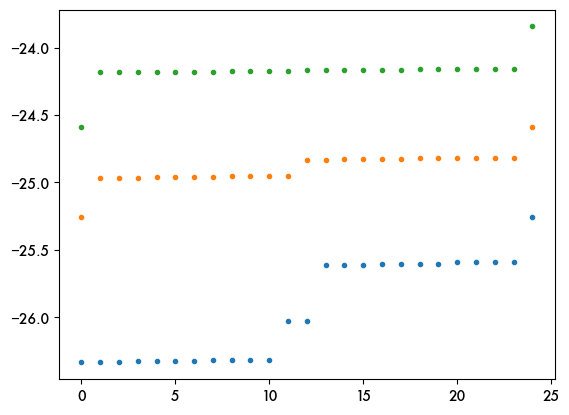

In [ ]:
for b in range(band):
    plt.plot(eig_sol[0][b] * V0, ".")